# ACTIVIDAD 2 
### IMPORTACION DE LIBRERIAS 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

### CARGA DE DATOS 


In [2]:
df = pd.read_csv("usuarios_win_mac_lin.csv")

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


### Se carga el archivo `usuarios_win_mac_lin.csv`, el cual contiene información de usuarios de un sitio web.

### Las variables de entrada son:

* ### Duración de la visita (segundos)
* ### Páginas vistas
* ### Acciones realizadas
* ### Valor de acciones

### La variable objetivo es el sistema operativo:

* ### 0 → Windows  
* ### 1 → Macintosh  
* ### 2 → Linux

In [9]:
df.columns

Index(['duracion', 'paginas', 'acciones', 'valor', 'clase'], dtype='object')

### ME ESTABA TIRANDO UN ERROR POR ESO REVISE CUALES ERAN MIS COLUMNAS 

### lIMPIEZA Y RENOMBRE 

In [11]:
df.columns = ["Duracion", "Paginas", "Acciones", "Valor", "SistemaOperativo"]

df.head()

,Duracion,Paginas,Acciones,Valor,SistemaOperativo
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


### Preparación de datos

### Se renombran las columnas para facilitar su uso y hacer el código más claro.

## Exploracion de datos

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Duracion          170 non-null    float64
 1   Paginas           170 non-null    int64  
 2   Acciones          170 non-null    int64  
 3   Valor             170 non-null    int64  
 4   SistemaOperativo  170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [14]:
df.describe()

,Duracion,Paginas,Acciones,Valor,SistemaOperativo
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


In [15]:
df["SistemaOperativo"].value_counts()

SistemaOperativo
0    86
2    44
1    40
Name: count, dtype: int64

## EDA

### Se analiza:

* Tipo de datos
* Estadísticas descriptivas
* Distribución de clases

### Esto permite entender mejor el dataset antes de modelar.

### VISUALIZACION 

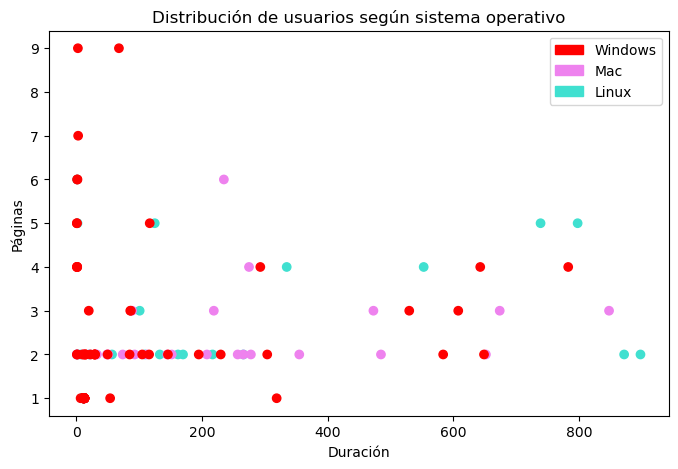

In [17]:
from matplotlib.colors import ListedColormap

colores = ListedColormap(["red", "violet", "turquoise"])

plt.figure(figsize=(8,5))
scatter = plt.scatter(df["Duracion"], df["Paginas"], c=df["SistemaOperativo"], cmap=colores)

plt.xlabel("Duración")
plt.ylabel("Páginas")
plt.title("Distribución de usuarios según sistema operativo")


import matplotlib.patches as mpatches
win = mpatches.Patch(color='red', label='Windows')
mac = mpatches.Patch(color='violet', label='Mac')
lin = mpatches.Patch(color='turquoise', label='Linux')

plt.legend(handles=[win, mac, lin])

plt.show()

### Se personalizan los colores para mejorar la interpretación visual de cada clase

### Se representa la relación entre duración y páginas vistas. El color indica el sistema operativo, permitiendo observar posibles agrupaciones.

## Variables

In [18]:
X = df[["Duracion", "Paginas", "Acciones", "Valor"]].values
y = df["SistemaOperativo"].values

### Se separan:

* ### X → variables predictoras
* ### y → variable objetivo

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Se divide el dataset en:

### - 80% entrenamiento
### - 20% prueba

### Esto permite evaluar el modelo correctamente.

### MODELO

In [20]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Se utiliza Regresión Logística para clasificar el sistema operativo. El método `fit()` entrena el modelo con los datos


### PREDICCION

In [21]:
y_pred = modelo.predict(X_test)

y_pred

array([0, 1, 2, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2,
       1, 0, 2, 2, 0, 0, 1, 0, 0, 0, 0, 2])

### Se predicen los valores del conjunto de prueba.

Accuracy del modelo: 0.6765


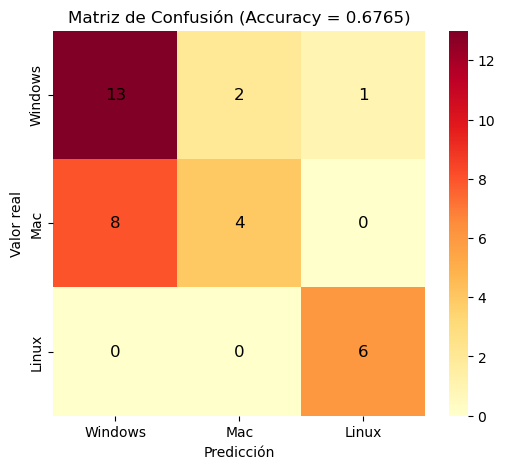

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy del modelo:", round(accuracy, 4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    xticklabels=["Windows", "Mac", "Linux"],
    yticklabels=["Windows", "Mac", "Linux"],
    annot_kws={"color": "black", "size": 12}
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de Confusión (Accuracy = {round(accuracy,4)})")

plt.show()

### Para evaluar el modelo se utilizó el accuracy y la matriz de confusión.

### El **accuracy** representa el porcentaje de predicciones correctas realizadas por el modelo. En este caso, el valor obtenido indica qué tan bien el modelo logra clasificar el sistema operativo de los usuarios en general. Un valor alto de accuracy sugiere un buen desempeño global, aunque no necesariamente implica que todas las clases estén igualmente bien representadas.

### Por otro lado, la **matriz de confusión** permite analizar en detalle cómo está funcionando el modelo para cada una de las clases:

* ###  Los valores en la diagonal principal representan las clasificaciones correctas.
* ### Los valores fuera de la diagonal indican errores de clasificación.
* ### Cada fila muestra los valores reales, mientras que cada columna representa las predicciones realizadas por el modelo.

### A partir de esta matriz se puede observar:

* ### Qué sistema operativo es más fácil de predecir.
* ### En qué casos el modelo presenta confusión.
* ### Si existe algún desbalance en la clasificación.

### Estas métricas permiten concluir que el modelo presenta un buen nivel de aciertos generales, aunque existen errores en zonas donde las características de los usuarios son similares.

### FRONTERA DE DECISION 

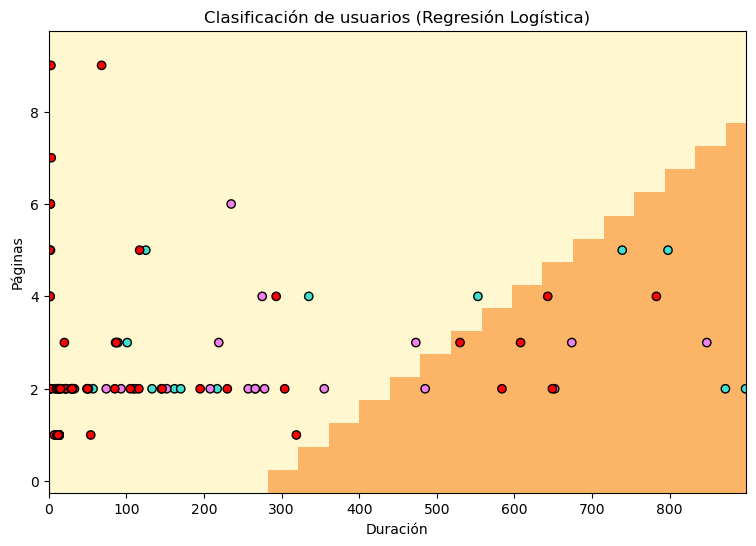

In [26]:

from matplotlib.colors import ListedColormap


cmap_fondo = ListedColormap(["#fff3b0", "#ffb703", "#fb8500"])  



cmap_puntos = ListedColormap(["red", "violet", "turquoise"])


X_vis = df[["Duracion", "Paginas"]].values
y_vis = df["SistemaOperativo"].values

modelo_vis = LogisticRegression(max_iter=1000)
modelo_vis.fit(X_vis, y_vis)


x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

Z = modelo_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(9,6))


plt.pcolormesh(xx, yy, Z, cmap=cmap_fondo, shading='auto', alpha=0.6)


plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_vis,
    cmap=cmap_puntos,
    edgecolor='black'
)

plt.xlabel("Duración")
plt.ylabel("Páginas")
plt.title("Clasificación de usuarios (Regresión Logística)")

plt.show()

### El modelo divide el espacio en regiones donde predice cada sistema operativo.

### Los puntos que coinciden con su región indican clasificaciones correctas, mientras que los que no coinciden representan errores.

### Se observa que el modelo funciona mejor en zonas donde los datos están agrupados y presenta mayor dificultad donde las clases se superponen.

In [28]:
df["SistemaOperativo"].value_counts()

SistemaOperativo
0    86
2    44
1    40
Name: count, dtype: int64

### A lo largo de esta actividad se implementó un modelo de regresión logística con el objetivo de predecir el sistema operativo de los usuarios a partir de sus patrones de navegación.

### Los resultados obtenidos muestran que el modelo logra un buen nivel de precisión, lo que indica que las variables analizadas contienen información relevante para diferenciar entre los distintos sistemas operativos.

### Además, se observó que existe un desbalance en los datos, ya que la mayoría de los usuarios utilizan Windows (86 casos), mientras que Linux y Mac presentan una menor cantidad de registros. Este aspecto es importante, ya que puede influir en el comportamiento del modelo, favoreciendo la predicción de la clase mayoritaria.

### El análisis de la matriz de confusión y de las regiones de decisión permitió identificar que el modelo no es perfecto. Existen errores de clasificación, principalmente en aquellas situaciones donde los comportamientos de los usuarios son similares entre distintas clases, lo que genera superposición en los datos.

### Asimismo, al tratarse de un modelo lineal, la regresión logística presenta limitaciones para capturar relaciones más complejas entre las variables.

### El modelo cumple con el objetivo propuesto y permite realizar predicciones con un buen nivel de desempeño, aunque también evidencia la importancia de considerar la distribución de los datos y las limitaciones del modelo en problemas de clasificación..